# KNN on Some Popular Dataset  

## Import the Required Libraries

In [21]:
# Import the Required Libraries
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn import datasets
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from knn import KNN

## Iris Dataset

In [4]:
iris = datasets.load_iris()
X, y = iris.data, iris.target

## Plot to Visualize Different Classes

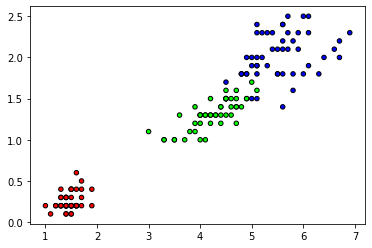

In [5]:
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])
plt.figure()
plt.scatter(X[:,2],X[:,3], c=y, cmap=cmap, edgecolor='k', s=20)
plt.show()

## Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Create the Model

In [7]:
clf = KNN(k=5)

## Train the Model

In [8]:
clf.fit(X_train, y_train)

## Make the Prediction

In [9]:
predictions = clf.predict(X_test)

## Get Accuracy

In [10]:
acc = np.sum(predictions == y_test) / len(y_test)
print("{:.2f}".format(acc))

0.97


## Make Prediction for New Data Point

In [11]:
clf.predict([[5.8, 2.8, 5.1, 2.4]])

[2]

In [12]:
from sklearn.metrics import accuracy_score

In [13]:
acc = accuracy_score(y_true=y_test,y_pred=predictions)
print("{:.2f}".format(acc))

0.97


## Use Scikit-Learn

In [14]:
from sklearn.neighbors import KNeighborsClassifier
clf_sci = KNeighborsClassifier(n_neighbors=5,p=2)
clf_sci.fit(X_train,y_train)
sci_pred = clf_sci.predict(X_test)
acc_sci = accuracy_score(y_true=y_test,y_pred=sci_pred)
print("{:.2f}".format(acc_sci))

0.97


# MNIST Handwritten Digit Dataset

In [23]:
digits = datasets.load_digits()
# Create features
X = digits.data

# Create target
y = digits.target

## Example of Each Digit 

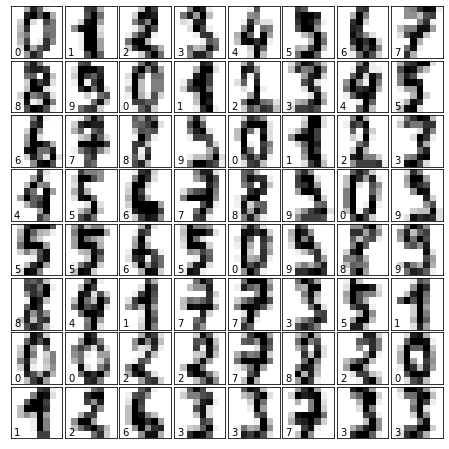

In [24]:
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

## Train Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Create and Train the Model

In [27]:
d_clf = KNN(k=5)
d_clf.fit(X_train,y_train)

## Make Prediction on Testset

In [29]:
pred = d_clf.predict(X_test)

## Get Accuracy

In [30]:
accuracy_score(pred,y_test)

0.975

## Making Prediction on New Image

### Function to Load and Preprocess Image

In [31]:
from PIL import Image

def load_image(image_path):
    # Open the image file
    image = Image.open(image_path)

    # Convert the image to grayscale
    image = image.convert('L')

    return image

def preprocess_image(image):
    # Resize the image to a suitable size for the classifier
    image = image.resize((8, 8), resample=Image.LANCZOS)

    # Convert the image to a numpy array
    image = np.array(image, dtype=np.float16)

    # Normalize the image (scale the pixel values to be between 0 and 16)
    image = image%28

    # Flatten the image to a 1-dimensional array
    image = image.flatten()

    return image

## Load the image and Make Prediction

In [32]:
# Load the image and preprocess it
image = load_image('4_image.jpg')
features = preprocess_image(image)

# Make a prediction using the classifier
prediction = d_clf.predict([features])

print("Predicted digit:", prediction[0])

Predicted digit: 7


c:\users\dipesh.poudel\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:14: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  


## Image After Pre-Processing

In [36]:
# Load the image and convert it to grayscale
image = Image.open('4_image.jpg').convert('L')

# Resize the image and normalize the pixel values
image = image.resize((8, 8), resample=Image.BOX)
image = np.array(image) % 17.0

# Flatten the image into a 1-dimensional array
image = image.flatten()


c:\users\dipesh.poudel\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: BOX is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.BOX instead.
  """


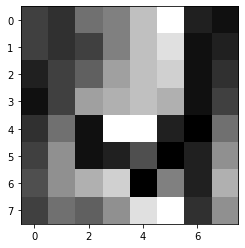

In [37]:
# Load the image data and reshape it into a 8x8 array
image = image.reshape((8, 8))

# Plot the image
plt.imshow(image, cmap='gray', vmin=0, vmax=16)
plt.show()